# GTSRB - German Traffic Sign Recognition Benchmark

## Project Overview
This project aims to develop a high-accuracy deep learning model for classifying traffic signs from the GTSRB dataset. The dataset consists of 43 different classes of traffic signs, ranging from speed limits to warning signs.

## Objectives
- Explore data augmentation and image processing techniques.
- Build and evaluate several CNN architectures.
- Optimize performance to achieve state-of-the-art results (Target: ~99.8%).

## Initial Setup and Documentation

### 1. Imports

**What:** We start by importing the standard libraries for deep learning, data manipulation, and visualization. We also add the `util` folder and the `src` folder to our path.

**Why:** These libraries provide the necessary tools for building and training neural networks (`torch`), handling images (`torchvision`, `PIL`), and visualizing data (`matplotlib`). Adding custom paths allows us to use project-specific helper functions.

In [1]:
import torch
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import shutil
import random
import time
from collections import Counter

# Add paths to import util and src modules
sys.path.append('../exemples/util')
sys.path.append('../src')

import vcpi_util
from fix_dataset import fix_and_recreate_split
from balance_dataset import balance_dataset

def show_random_samples(dataset, classes, title="Dataset Samples", num_rows=3, num_cols=5):
    """
    Visualizes a grid of random samples from a given dataset.
    What: Picks random indices and displays the images with their labels.
    Why: To visually inspect the data and ensure loading/transforms are correct.
    """
    indices = random.sample(range(len(dataset)), num_rows * num_cols)
    images = [dataset[i][0] for i in indices]
    targets = [dataset[i][1] for i in indices]
    
    print(title)
    vcpi_util.show_images(num_rows, num_cols, images, targets, classes)


### 2. Device Configuration and Global Settings

**What:** We check for GPU availability using `torch.cuda.is_available()` and define all base paths and configuration parameters.

**Why:** GPUs are specialized hardware that can process large batches of data in parallel, making them much faster than CPUs for training neural networks. Defining a `device` variable allows us to write hardware-agnostic code.

#### Variable Documentation:
- `device`: (torch.device) The hardware used for training (CUDA if a GPU is detected, otherwise CPU).
- `RESET_DATASET`: (bool) When True, the validation split is recreated from the origin images and the training set is re-balanced.
- `PATH_ORIGIN`: (str) Path to the untouched GTSRB training images.
- `PATH_TRAIN_ROOT`: (str) Path where the split training set (before balancing) is stored.
- `PATH_TRAIN_BALANCED`: (str) Path where the augmented and balanced training set is stored.
- `PATH_TEST`: (str) Path to the testing images.
- `PATH_VAL`: (str) Path to the validation images.
- `BATCH_SIZE`: (int) Number of samples per training step.
- `IMAGE_SIZE`: (int) Target resolution for all images (32x32).
- `AUGMENTATION_OPTIONS`: (dict) Configuration flags for the static balancing process.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

RESET_DATASET = False

PATH_ORIGIN = '../datasets/origin_train_images'
PATH_TRAIN_ROOT = '../datasets/train_images'
PATH_TRAIN_BALANCED = '../datasets/train_balanced'
PATH_TEST = '../datasets/test_images'
PATH_VAL = '../datasets/val_images'

BATCH_SIZE = 32
IMAGE_SIZE = 32

AUGMENTATION_OPTIONS = {
    'rotate': True,
    'affine': True,
    'color': True,           
    'perspective': True      
}

if RESET_DATASET:
    print("Resetting dataset as requested...")
    fix_and_recreate_split(PATH_ORIGIN, PATH_TRAIN_ROOT, PATH_VAL)
    balance_dataset(PATH_TRAIN_ROOT, PATH_TRAIN_BALANCED, target_count=2000, options=AUGMENTATION_OPTIONS)
else:
    if not os.path.exists(PATH_TRAIN_ROOT) or not os.path.exists(PATH_VAL):
        fix_and_recreate_split(PATH_ORIGIN, PATH_TRAIN_ROOT, PATH_VAL)
    if not os.path.exists(PATH_TRAIN_BALANCED):
        balance_dataset(PATH_TRAIN_ROOT, PATH_TRAIN_BALANCED, target_count=2000, options=AUGMENTATION_OPTIONS)

Using device: cuda


### 3. Loading the Datasets

**What:** We load the datasets using `torchvision.datasets.ImageFolder`.

**Why:** `ImageFolder` is an efficient way to load images organized in class-labeled folders. We apply a basic `Resize` and `ToTensor` transform to prepare the data for the model.

**Variable Documentation:**
- `transform`: (Compose) The list of transformations applied to every image upon loading (Resize + ToTensor).

In [3]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

train_set = datasets.ImageFolder(root=PATH_TRAIN_ROOT, transform=transform)
val_set = datasets.ImageFolder(root=PATH_VAL, transform=transform)
test_set = datasets.ImageFolder(root=PATH_TEST, transform=transform)
train_set_balanced = datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform)

print(f"Original Training samples: {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Testing samples: {len(test_set)}")
print(f"Balanced Training samples: {len(train_set_balanced)}")

Original Training samples: 28738
Validation samples: 6609
Testing samples: 12630
Balanced Training samples: 86000


### 4. Visual Inspection of Loaded Data

**What:** We display a grid of random samples from each of the main dataset splits.

**Why:** This helps us confirm that the labels match the images and that the images were loaded correctly into our desired resolution.

Random Training Samples


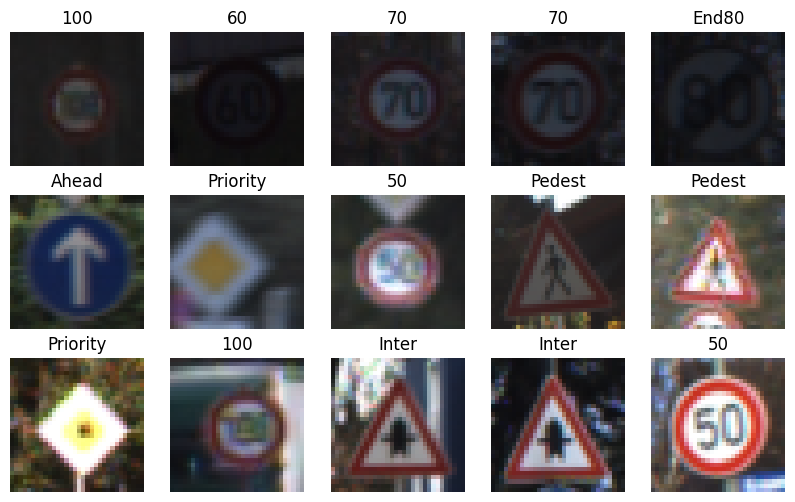

<Figure size 640x480 with 0 Axes>

Random Validation Samples


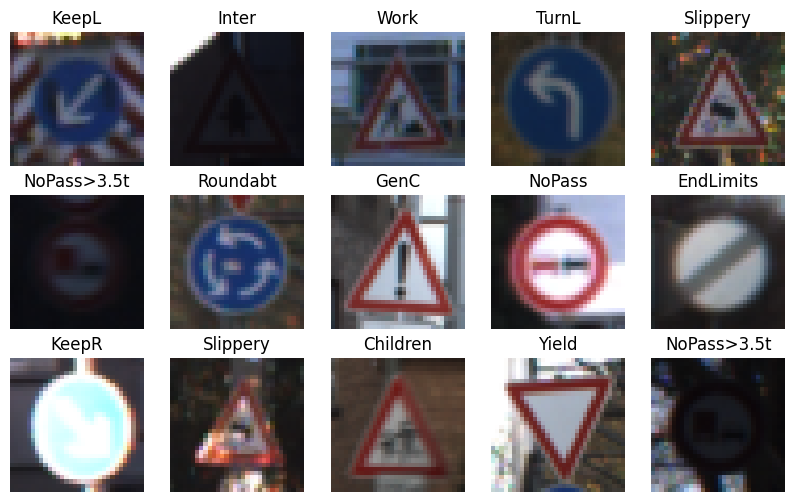

<Figure size 640x480 with 0 Axes>

Random Test Samples


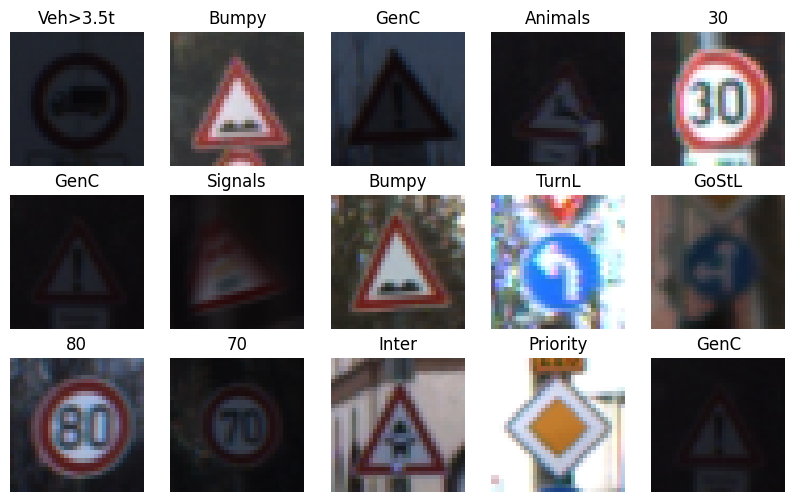

<Figure size 640x480 with 0 Axes>

In [4]:
classes = [
    '20', '30', '50', '60', '70', '80', 'End80', '100', '120', 
    'NoPass', 'NoPass>3.5t', 'Inter', 'Priority', 'Yield', 
    'Stop', 'NoVeh', 'Veh>3.5t', 'NoEntry', 'GenC', 'CurveL', 
    'CurveR', 'DoubleC', 'Bumpy', 'Slippery', 'NarrowR', 'Work', 
    'Signals', 'Pedest', 'Children', 'Bicycles', 'Ice', 'Animals', 
    'EndLimits', 'TurnR', 'TurnL', 'Ahead', 'GoStR', 'GoStL', 
    'KeepR', 'KeepL', 'Roundabt', 'EndNoP', 'EndNoP>3.5t'
]

show_random_samples(train_set, classes, "Random Training Samples")
show_random_samples(val_set, classes, "Random Validation Samples")
show_random_samples(test_set, classes, "Random Test Samples")

### 5. Class Distribution Analysis

**What:** We use histograms to visualize the number of samples available for each traffic sign class.

**Why:** GTSRB is notoriously imbalanced. Visualizing this allows us to understand the extent of the imbalance and justifies the need for Phase 2 (Balancing).

Analyzing Training Set distribution:
Counter({1: 1630, 2: 1605, 13: 1565, 38: 1513, 12: 1496, 10: 1467, 4: 1439, 5: 1364, 25: 1084, 9: 1080, 7: 1077, 3: 1037, 8: 1033, 11: 949, 35: 867, 18: 861, 17: 809, 14: 568, 31: 555, 33: 505, 15: 458, 26: 433, 28: 410, 23: 392, 30: 333, 6: 325, 34: 325, 16: 321, 22: 294, 36: 289, 20: 270, 40: 269, 21: 243, 39: 221, 24: 213, 29: 207, 42: 187, 32: 186, 41: 184, 27: 182, 19: 167, 37: 163, 0: 162})


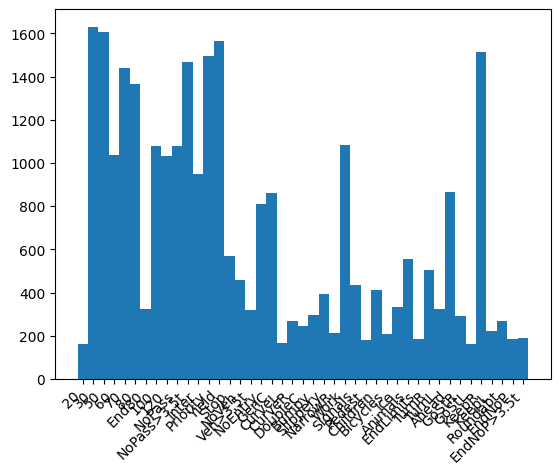

Analyzing Validation Set distribution:
Counter({2: 411, 13: 385, 1: 383, 12: 378, 10: 360, 38: 356, 4: 342, 5: 324, 25: 274, 9: 250, 8: 248, 7: 246, 3: 241, 18: 224, 11: 214, 35: 210, 17: 192, 14: 140, 31: 132, 15: 113, 26: 109, 33: 108, 28: 84, 23: 81, 30: 76, 6: 59, 34: 56, 36: 56, 20: 55, 21: 54, 16: 53, 39: 53, 40: 52, 22: 49, 19: 29, 42: 29, 32: 28, 37: 28, 24: 27, 0: 26, 27: 25, 29: 25, 41: 24})


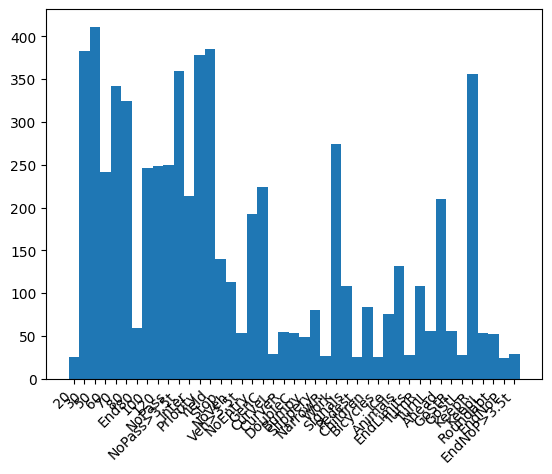

In [5]:
print("Analyzing Training Set distribution:")
train_targets_tensors = [torch.tensor(x) for x in train_set.targets]
vcpi_util.show_histogram(train_targets_tensors, classes)

print("Analyzing Validation Set distribution:")
val_targets_tensors = [torch.tensor(x) for x in val_set.targets]
vcpi_util.show_histogram(val_targets_tensors, classes)

# Phase 2: Data Balancing & Augmentation

**What:** We apply static data augmentation to minority classes until all classes reach a target of 2000 images.

**Why:** A balanced dataset ensures the model's loss function doesn't ignore rare classes. By using transformations like rotation, affine shifts, and color adjustments, we also make the model more robust to real-world variations.

**Transformation Details:**
- **Rotation**: Simulates signs that are not perfectly level.
- **Affine**: Simulates translation and shearing of the sign perspective.
- **Color Jitter**: Simulates different lighting conditions (brightness, contrast).
- **Perspective**: Simulates viewing the sign from different angles.

Analyzing Balanced Training Set distribution:
Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000, 10: 2000, 11: 2000, 12: 2000, 13: 2000, 14: 2000, 15: 2000, 16: 2000, 17: 2000, 18: 2000, 19: 2000, 20: 2000, 21: 2000, 22: 2000, 23: 2000, 24: 2000, 25: 2000, 26: 2000, 27: 2000, 28: 2000, 29: 2000, 30: 2000, 31: 2000, 32: 2000, 33: 2000, 34: 2000, 35: 2000, 36: 2000, 37: 2000, 38: 2000, 39: 2000, 40: 2000, 41: 2000, 42: 2000})


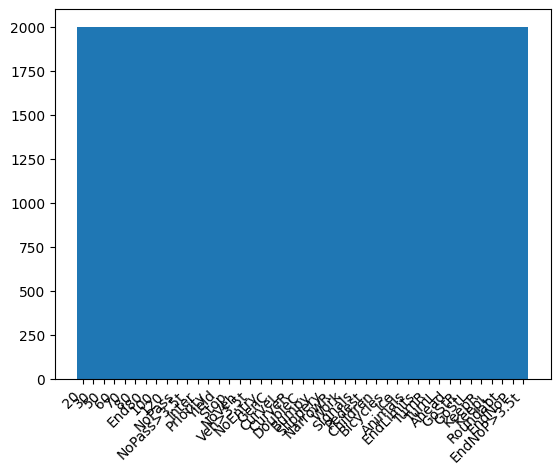

Random Balanced Training Samples (Augmented)


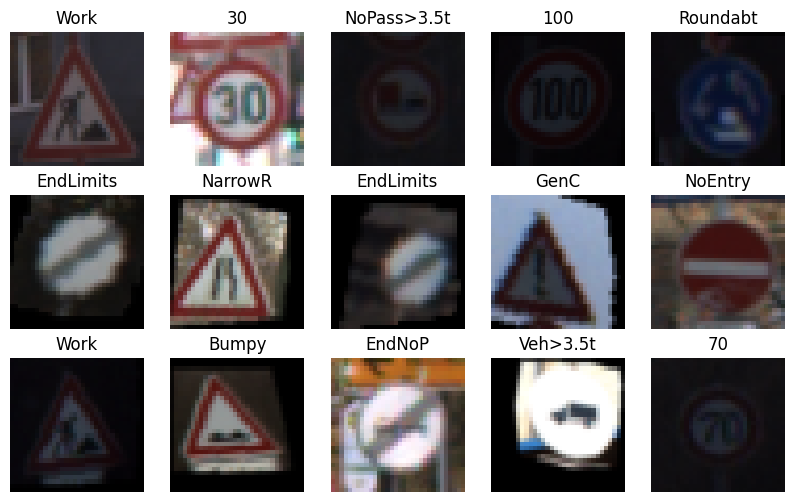

<Figure size 640x480 with 0 Axes>

In [6]:
print("Analyzing Balanced Training Set distribution:")
train_balanced_targets_tensors = [torch.tensor(x) for x in train_set_balanced.targets]
vcpi_util.show_histogram(train_balanced_targets_tensors, classes)

show_random_samples(train_set_balanced, classes, "Random Balanced Training Samples (Augmented)")

# Phase 3: Model Development & Training

### 1. Training Infrastructure

**What:** We define helper classes and functions for the training process, including `Early_Stopping` and `train_model`.

**Why:** A robust training loop needs to handle data transfers to the GPU, monitor validation performance, and stop training early if the model stops improving to prevent overfitting.

#### Variable Documentation:
- `Early_Stopping`: (class) Monitors validation loss and stops training if it hasn't improved for a certain number of epochs (`patience`).
- `train_model`: (function) The main loop that performs forward/backward passes and updates model weights.

In [7]:
class Early_Stopping():
    def __init__(self, patience = 5, min_delta = 0.00001):
        self.patience = patience 
        self.min_delta = min_delta
        self.min_val_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
        return False

def train_model(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, device, save_prefix = 'model'):
    history = {'accuracy': [], 'val_acc': [], 'val_loss': [], 'loss': []}
    best_val_loss = np.inf
    model.to(device)

    for epoch in range(epochs):
        model.train()
        start_time = time.time()
        correct = 0
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == targets).sum().item()

        model.eval()
        v_correct = 0
        v_running_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = loss_fn(outputs, targets)
                v_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                v_correct += (predicted == targets).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_epoch_loss = v_running_loss / len(val_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        
        scheduler.step(v_epoch_loss)
        
        history['accuracy'].append(accuracy)
        history['loss'].append(epoch_loss)
        history['val_acc'].append(v_accuracy)
        history['val_loss'].append(v_epoch_loss)
        
        elapsed = time.time() - start_time
        print(f'Epoch {epoch+1:03d}: Loss: {epoch_loss:.4f}, Acc: {accuracy:.2f}%, Val Loss: {v_epoch_loss:.4f}, Val Acc: {v_accuracy:.2f}%, Time: {elapsed:.2f}s')

        if v_epoch_loss < best_val_loss:
            best_val_loss = v_epoch_loss
            torch.save(model.state_dict(), f'{save_prefix}_best.pt')

        if early_stopper(v_epoch_loss):
            print('Early stopping triggered.')
            break
            
    return history

### 2. Baseline Architecture

**What:** We define a simple Convolutional Neural Network (CNN) as our baseline.

**Why:** A baseline model allows us to establish a starting point for performance. Any future improvements (like BatchNorm or Dropout) should be measured against this version.

#### Variable Documentation:
- `BaselineCNN`: (class) A simple architecture with 2 convolutional layers and one fully connected layer.

In [8]:
class BaselineCNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(16, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.fc = torch.nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

### 3. Hyperparameter Configuration and Execution

**What:** We initialize the Baseline model, loss function, and optimizer, then start the training process.

**Why:** Proper hyperparameter selection is key to convergence. We use `CrossEntropyLoss` for our multi-class problem and `Adam` for efficient weight updates.

#### Variable Documentation:
- `EPOCHS`: (int) Maximum number of training iterations.
- `LEARNING_RATE`: (float) Size of the steps taken during weight optimization.
- `optimizer`: (torch.optim) The algorithm used to update weights (Adam).
- `scheduler`: (torch.optim.lr_scheduler) Dynamically reduces the learning rate when validation loss plateaus.

In [9]:
EPOCHS = 30
LEARNING_RATE = 0.001

train_loader_balanced = torch.utils.data.DataLoader(train_set_balanced, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

model_baseline = BaselineCNN(len(classes))
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopper = Early_Stopping(patience=5)

history_baseline = train_model(
    model_baseline, 
    train_loader_balanced, 
    val_loader, 
    EPOCHS, 
    loss_fn, 
    optimizer, 
    scheduler, 
    early_stopper, 
    device, 
    save_prefix='baseline'
)

Epoch 001: Loss: 1.2405, Acc: 65.94%, Val Loss: 0.7474, Val Acc: 78.73%, Time: 622.11s
Epoch 002: Loss: 0.4596, Acc: 87.19%, Val Loss: 0.5703, Val Acc: 84.23%, Time: 110.21s
Epoch 003: Loss: 0.2920, Acc: 91.74%, Val Loss: 0.5056, Val Acc: 87.99%, Time: 99.64s
Epoch 004: Loss: 0.2115, Acc: 93.90%, Val Loss: 0.4724, Val Acc: 88.32%, Time: 442.65s
Epoch 005: Loss: 0.1615, Acc: 95.34%, Val Loss: 0.5719, Val Acc: 86.68%, Time: 161.36s
Epoch 006: Loss: 0.1283, Acc: 96.20%, Val Loss: 0.5431, Val Acc: 87.91%, Time: 50.16s
Epoch 007: Loss: 0.1041, Acc: 96.85%, Val Loss: 0.5176, Val Acc: 88.56%, Time: 52.53s
Epoch 008: Loss: 0.0869, Acc: 97.38%, Val Loss: 0.5107, Val Acc: 88.88%, Time: 58.19s
Epoch 009: Loss: 0.0378, Acc: 99.03%, Val Loss: 0.4740, Val Acc: 90.20%, Time: 57.06s
Epoch 010: Loss: 0.0295, Acc: 99.32%, Val Loss: 0.4883, Val Acc: 90.59%, Time: 57.12s
Early stopping triggered.


### 4. Evaluating Results

**What:** We plot the accuracy and loss histories to visualize the training progress.

**Why:** Plots help us identify if the model is overfitting (divergence between train and val loss) or if it has reached a stable performance level.

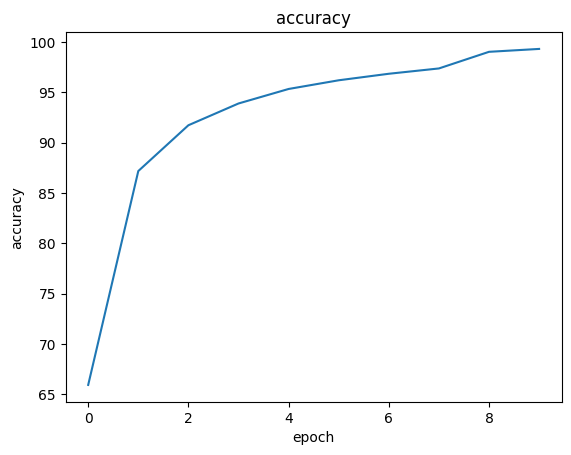

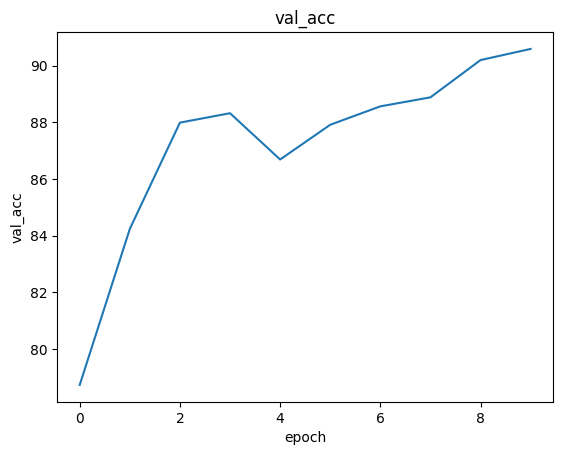

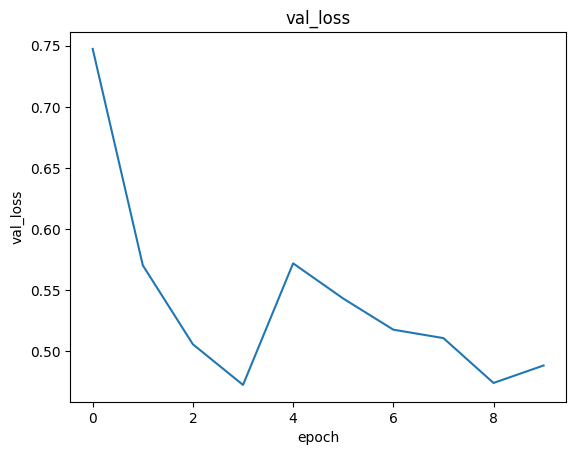

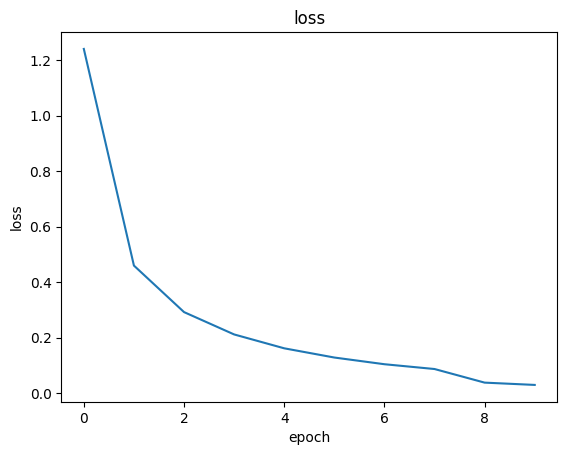

In [10]:
vcpi_util.show_history(history_baseline)

### 5. Test Set Evaluation

**What:** We evaluate the final performance of the baseline model on the unseen Test Set.

**Why:** The test set is the ultimate benchmark. Performance here reflects how the model will behave in the real world. We use the best weights saved during training (`baseline_best.pt`) to ensure we are testing the most optimized version of the model.

#### Variable Documentation:
- `test_loader`: (DataLoader) Iterator for the test set.

Final Test Accuracy: 88.90%
Confusion Matrix:


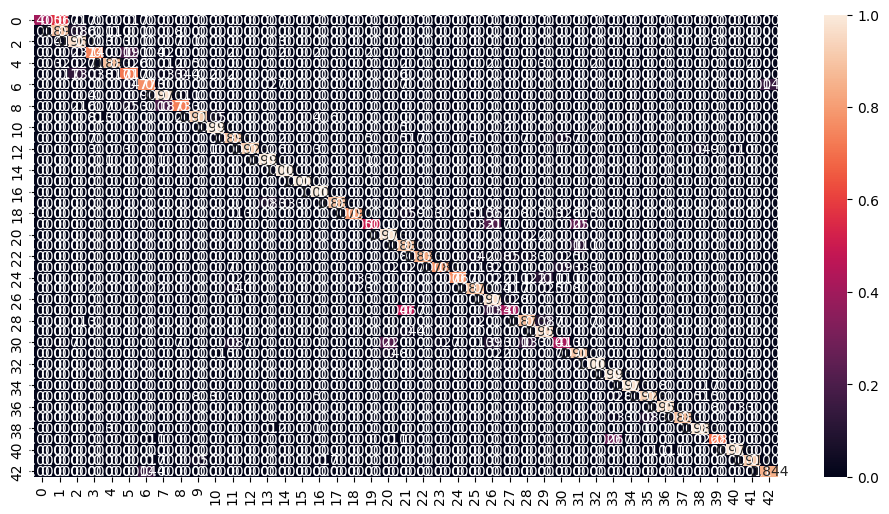

In [11]:
def evaluate_test_set(model, test_loader, device, weights_path):
    # Load the best weights
    model.load_state_dict(torch.load(weights_path))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    correct = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == targets).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    test_accuracy = 100 * correct / len(test_loader.dataset)
    print(f"Final Test Accuracy: {test_accuracy:.2f}%")
    
    return all_targets, all_preds

test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
targets, preds = evaluate_test_set(model_baseline, test_loader, device, 'baseline_best.pt')

print("Confusion Matrix:")
vcpi_util.show_confusion_matrix(targets, preds, len(classes))

## Dynamic Data Augmentation
**What:** In this section, we apply online data augmentation directly in the training pipeline.

**Why:** Unlike offline augmentation, where transformed images are generated once and saved to disk, dynamic augmentation applies random transformations every time an image is loaded during training. This increases data variability across epochs and can improve generalization.

**Important:** Dynamic augmentation is applied only to the training set. Validation and test sets keep deterministic preprocessing to ensure a fair evaluation.

In [12]:
dynamic_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(12),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05),
        shear=8
    ),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [13]:
train_set_balanced_dynamic = datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=dynamic_train_transform)
val_set_dynamic = datasets.ImageFolder(root=PATH_VAL, transform=eval_transform)
test_set_dynamic = datasets.ImageFolder(root=PATH_TEST, transform=eval_transform)

Random Dynamic Augmented Training Samples


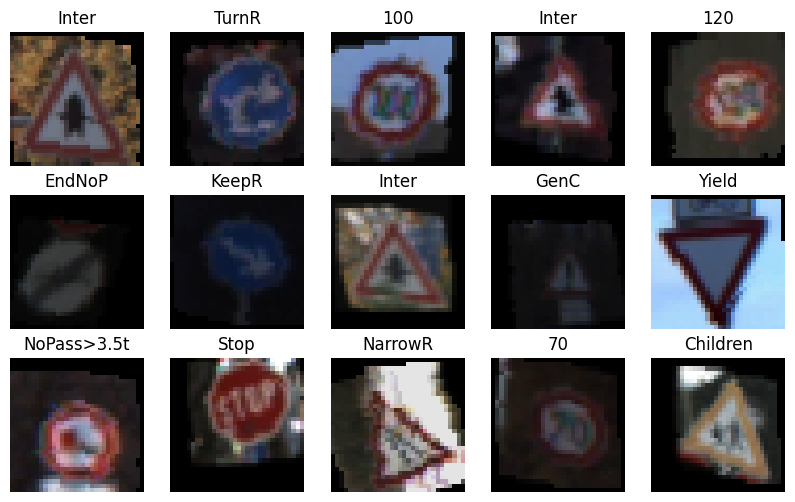

<Figure size 640x480 with 0 Axes>

In [14]:
show_random_samples(train_set_balanced_dynamic, classes, "Random Dynamic Augmented Training Samples")

In [15]:
train_loader_balanced_dynamic = torch.utils.data.DataLoader(
    train_set_balanced_dynamic,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_dynamic = torch.utils.data.DataLoader(
    val_set_dynamic,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [16]:
model_dynamic = BaselineCNN(len(classes))
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dynamic.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)
early_stopper = Early_Stopping(patience=5)

history_dynamic = train_model(
    model_dynamic,
    train_loader_balanced_dynamic,
    val_loader_dynamic,
    EPOCHS,
    loss_fn,
    optimizer,
    scheduler,
    early_stopper,
    device,
    save_prefix='baseline_dynamic'
)

Epoch 001: Loss: 1.8545, Acc: 46.72%, Val Loss: 1.1268, Val Acc: 65.56%, Time: 96.48s
Epoch 002: Loss: 1.0129, Acc: 70.70%, Val Loss: 0.9154, Val Acc: 73.10%, Time: 96.48s
Epoch 003: Loss: 0.7515, Acc: 78.44%, Val Loss: 0.8718, Val Acc: 74.66%, Time: 95.07s
Epoch 004: Loss: 0.6201, Acc: 82.30%, Val Loss: 0.8087, Val Acc: 78.08%, Time: 93.76s
Epoch 005: Loss: 0.5302, Acc: 84.91%, Val Loss: 0.8138, Val Acc: 78.27%, Time: 90.51s
Epoch 006: Loss: 0.4792, Acc: 86.13%, Val Loss: 0.6872, Val Acc: 81.81%, Time: 97.60s
Epoch 007: Loss: 0.4363, Acc: 87.30%, Val Loss: 0.6746, Val Acc: 82.92%, Time: 91.96s
Epoch 008: Loss: 0.4082, Acc: 88.13%, Val Loss: 0.7006, Val Acc: 81.99%, Time: 90.85s
Epoch 009: Loss: 0.3796, Acc: 88.86%, Val Loss: 0.6689, Val Acc: 83.05%, Time: 97.40s
Epoch 010: Loss: 0.3625, Acc: 89.50%, Val Loss: 0.6944, Val Acc: 83.17%, Time: 97.17s
Epoch 011: Loss: 0.3403, Acc: 90.18%, Val Loss: 0.6835, Val Acc: 83.13%, Time: 97.42s
Epoch 012: Loss: 0.3274, Acc: 90.49%, Val Loss: 0.6681

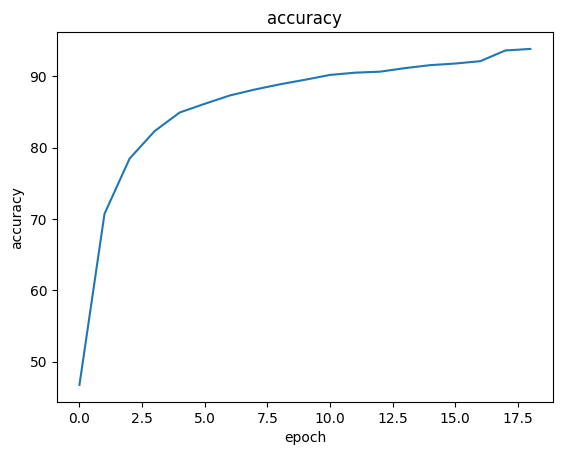

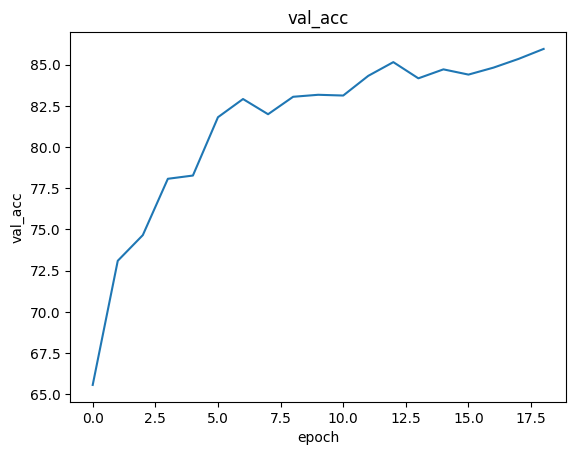

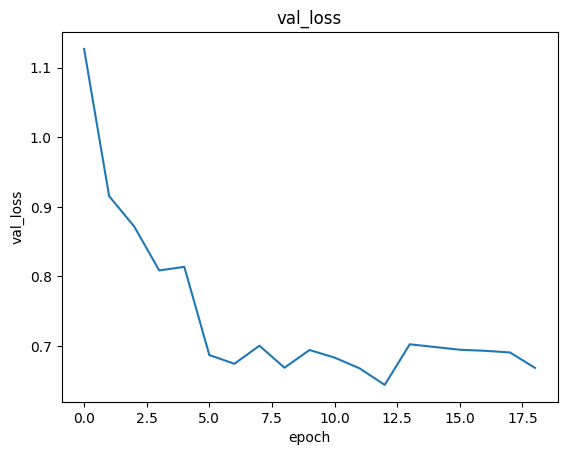

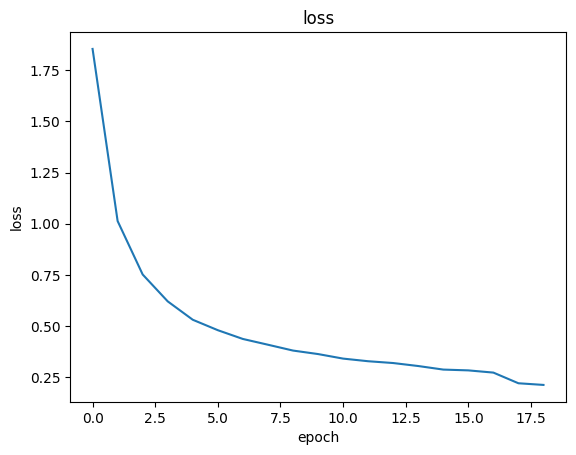

In [17]:
vcpi_util.show_history(history_dynamic)

Final Test Accuracy: 84.88%
Dynamic Augmentation Confusion Matrix:


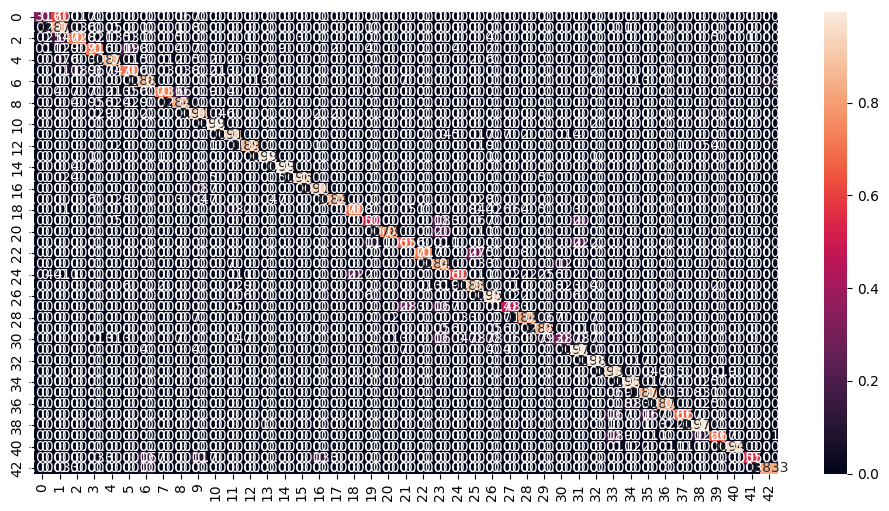

In [18]:
test_loader_dynamic = torch.utils.data.DataLoader(
    test_set_dynamic,
    batch_size=BATCH_SIZE,
    shuffle=False
)

targets_dynamic, preds_dynamic = evaluate_test_set(
    model_dynamic,
    test_loader_dynamic,
    device,
    'baseline_dynamic_best.pt'
)

print("Dynamic Augmentation Confusion Matrix:")
vcpi_util.show_confusion_matrix(targets_dynamic, preds_dynamic, len(classes))

In [19]:
print("Final validation accuracy (static only):", history_baseline['val_acc'][-1])
print("Best validation accuracy (static only):", max(history_baseline['val_acc']))

print("Final validation accuracy (static + dynamic):", history_dynamic['val_acc'][-1])
print("Best validation accuracy (static + dynamic):", max(history_dynamic['val_acc']))

Final validation accuracy (static only): 90.58859131487365
Best validation accuracy (static only): 90.58859131487365
Final validation accuracy (static + dynamic): 85.95854138296262
Best validation accuracy (static + dynamic): 85.95854138296262
